In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as Func
import numpy as np
import time
import re
import pickle
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

## CNN+LSTM

**Конфигурация CNN (самое важное):**

- *DATA_TYPE:* "stack", если подается вектор конкатенации поднесущих 3-х устройств [esp1(shape n_subcarry x 1), esp2(shape n_subcarry x 1), esp3(shape n_subcarry x 1)], "avg" для усредненного вектора (shape n_subcarry x 1)
- *CONV1_FILTERS:* глубина свертки
- *NUM_LAYERS:* количество LSTM блоков в модели
- *HIDDEN_SIZE:* размерность h (вектора внутреннего состояния) LSTM
- *DROPOUT:* отбрасывается указанная доля входных сигналов (действует как регуляризация)
- *ATTENTION_SIZE:* размерность слоя внимания
- *WEIGHT_DECAY:* уровень регуляризации (1е-4 - 1е-3)
- *EPOCHS:* максимальное число эпох
- *EARLY_STOP_PATIENCE:* после данного числа эпох без улучшения сработает ранняя остановка
- *MOTION_LOSS_WEIGHT, DISTANCE_LOSS_WEIGHT:* веса каждой из задач при расчете функции потерь

`Замечание:` для воспроизводимости параметры выставляются аналогичными тем, что были при обучении

In [ ]:
class ConfigCNN:
    DATA_TYPE = "stack"
    N_SUBCARRIERS = 52
    N_MOTION_CLASSES = 2
    N_DISTANCE_CLASSES = 4
    CONV1_FILTERS = 64
    CONV1_KERNEL = 3
    CONV2_FILTERS = 128
    CONV2_KERNEL = 3
    HIDDEN_SIZE = 64
    NUM_LAYERS = 2
    DROPOUT = 0.35
    BIDIRECTIONAL = True
    USE_ATTENTION = True
    ATTENTION_SIZE = 64

class TemporalAttention(nn.Module):
    def __init__(self, hidden_size, attention_size):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, attention_size),
            nn.Tanh(),
            nn.Linear(attention_size, 1)
        )
    def forward(self, lstm_output):
        weights = self.attention(lstm_output).squeeze(-1)
        weights = Func.softmax(weights, dim=1)
        context = torch.sum(lstm_output * weights.unsqueeze(-1), dim=1)
        return context, weights

class CSI_CNN_LSTM_Attention(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        input_channels = config.N_SUBCARRIERS * 3
        self.conv1 = nn.Conv1d(input_channels, config.CONV1_FILTERS,
                               kernel_size=config.CONV1_KERNEL, padding='same')
        self.bn1 = nn.BatchNorm1d(config.CONV1_FILTERS)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(config.CONV1_FILTERS, config.CONV2_FILTERS,
                               kernel_size=config.CONV2_KERNEL, padding='same')
        self.bn2 = nn.BatchNorm1d(config.CONV2_FILTERS)
        self.pool2 = nn.MaxPool1d(2)
        self.lstm = nn.LSTM(
            input_size=config.CONV2_FILTERS,
            hidden_size=config.HIDDEN_SIZE,
            num_layers=config.NUM_LAYERS,
            batch_first=True,
            dropout=config.DROPOUT if config.NUM_LAYERS > 1 else 0,
            bidirectional=config.BIDIRECTIONAL
        )
        lstm_out_size = config.HIDDEN_SIZE * 2 if config.BIDIRECTIONAL else config.HIDDEN_SIZE
        self.use_attention = config.USE_ATTENTION
        if self.use_attention:
            self.attention = TemporalAttention(lstm_out_size, config.ATTENTION_SIZE)
            fc_in = lstm_out_size
        else:
            self.attention = None
            fc_in = lstm_out_size
        self.motion_head = nn.Sequential(
            nn.Linear(fc_in, 64),
            nn.ReLU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(64, config.N_MOTION_CLASSES)
        )
        self.distance_head = nn.Sequential(
            nn.Linear(fc_in, 64),
            nn.ReLU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(64, config.N_DISTANCE_CLASSES)
        )
    def forward(self, x):
        B, T, F, D = x.shape
        x = x.permute(0, 3, 2, 1).reshape(B, F * D, T)
        x = self.pool1(Func.relu(self.bn1(self.conv1(x))))
        x = self.pool2(Func.relu(self.bn2(self.conv2(x))))
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        if self.use_attention:
            context, attn = self.attention(lstm_out)
        else:
            context = lstm_out[:, -1, :]
            attn = None
        motion_logits = self.motion_head(context)
        distance_logits = self.distance_head(context)
        return motion_logits, distance_logits, attn

**Конфигурация Mamba (самое важное):**

- *DATA_TYPE:* "stack", если подается вектор конкатенации поднесущих 3-х устройств [esp1(shape n_subcarry x 1), esp2(shape n_subcarry x 1), esp3(shape n_subcarry x 1)], "avg" для усредненного вектора (shape n_subcarry x 1)
- *WINDOW_SIZE:* размер окна для рекуррентной модели (на выходе используется конкатеницая всех скрытых состояний)
- *N_FEATURES:* количество поднесущих
- *D_MODEL:* размерность выходного вектора и промежуточных состояний в mamba
- N_LAYERS: количество Mamba+CNN блоков в модели
- *HIDDEN_SIZE:* размерность h (вектора внутреннего состояния) LSTM
- *DROPOUT:* отбрасывается указанная доля входных сигналов (действует как регуляризация)
- *WEIGHT_DECAY:* уровень регуляризации (1е-4 - 1е-3)
- *EPOCHS:* максимальное число эпох
- *EARLY_STOP_PATIENCE:* после данного числа эпох без улучшения сработает ранняя остановка
- *MOTION_LOSS_WEIGHT, DISTANCE_LOSS_WEIGHT:* веса каждой из задач при расчете функции потерь

`Замечание:` для воспроизводимости параметры выставляются аналогичными тем, что были при обучении

In [ ]:
class ConfigMamba:
    DATA_TYPE = "stack"
    WINDOW_SIZE = 100
    N_FEATURES = 52
    D_MODEL = 32
    N_LAYERS = 2
    D_STATE = 16
    DT_RANK = 4
    D_CONV = 4
    EXPAND_FACTOR = 2.0
    N_HEADS = 4
    DROPOUT = 0.5
    N_MOTION_CLASSES = 2
    N_DISTANCE_CLASSES = 4
    INPUT_CONV_KERNEL = 7
    POOL_SIZE = 2

class RMSNorm(nn.Module):
    def __init__(self, d, eps=1e-6):
        super().__init__()
        self.eps = eps
        self.weight = nn.Parameter(torch.ones(d))
    def forward(self, x):
        rms = torch.sqrt(torch.mean(x**2, dim=-1, keepdim=True) + self.eps)
        return x / rms * self.weight

class SelectiveSSM(nn.Module):
    def __init__(self, d_model, d_state=16, dt_rank=None, delta_softplus=True):
        super().__init__()
        self.d_model = d_model
        self.d_state = d_state
        self.dt_rank = dt_rank if dt_rank is not None else max(1, d_model // 16)
        self.delta_softplus = delta_softplus
        self.x_proj = nn.Linear(d_model, self.dt_rank + d_state * 2, bias=False)
        self.dt_proj = nn.Linear(self.dt_rank, 1)
        self.x_proj_state = nn.Linear(d_model, d_state, bias=False)
        A = torch.arange(1, d_state + 1).float().view(1, d_state)
        A = -torch.exp(A)
        self.A_log = nn.Parameter(torch.log(-A))
        self.out_proj = nn.Linear(d_state, d_model, bias=False)
        self.D = nn.Parameter(torch.ones(d_model))
    def forward(self, x):
        B, L, D = x.shape
        N = self.d_state
        proj = self.x_proj(x)
        dt_rank_part = proj[..., :self.dt_rank]
        B_part = proj[..., self.dt_rank:self.dt_rank + N]
        C_part = proj[..., self.dt_rank + N:]
        dt = self.dt_proj(dt_rank_part)
        if self.delta_softplus:
            dt = Func.softplus(dt)
        A = -torch.exp(self.A_log)
        A_bar = torch.exp(dt * A)
        B_bar = dt * B_part
        x_state = self.x_proj_state(x)
        h = torch.zeros(B, N, device=x.device, dtype=x.dtype)
        outputs = []
        for t in range(L):
            h = A_bar[:, t] * h + B_bar[:, t] * x_state[:, t]
            y_t = self.out_proj(h * C_part[:, t])
            outputs.append(y_t.unsqueeze(1))
        y = torch.cat(outputs, dim=1)
        y = y + self.D * x
        return y

class MambaBranch(nn.Module):
    def __init__(self, d_model, d_state=16, expand_factor=2, conv_kernel=4, dropout=0.1):
        super().__init__()
        self.norm = RMSNorm(d_model)
        d_inner = int(d_model * expand_factor)
        self.in_proj = nn.Linear(d_model, d_inner * 2, bias=False)
        self.conv1d = nn.Conv1d(d_inner, d_inner, kernel_size=conv_kernel, padding=conv_kernel-1, groups=d_inner)
        self.ssm = SelectiveSSM(d_inner, d_state)
        self.out_proj = nn.Linear(d_inner, d_model, bias=False)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        residual = x
        x = self.norm(x)
        x_proj = self.in_proj(x)
        x_ssm, gate = x_proj.chunk(2, dim=-1)
        x_ssm = self.conv1d(x_ssm.transpose(1,2)).transpose(1,2)[:, :x.size(1), :]
        x_ssm = Func.silu(x_ssm)
        x_ssm = self.ssm(x_ssm)
        gate = Func.silu(gate)
        x = x_ssm * gate
        x = self.out_proj(x)
        x = self.dropout(x)
        return residual + x

class ConvBranch(nn.Module):
    def __init__(self, d_model, kernel_size=3, dropout=0.1):
        super().__init__()
        self.norm = RMSNorm(d_model)
        self.conv = nn.Conv1d(d_model, d_model, kernel_size=kernel_size, padding=kernel_size//2, groups=d_model)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        residual = x
        x = self.norm(x)
        x = self.conv(x.transpose(1,2)).transpose(1,2)
        x = self.act(x)
        x = self.dropout(x)
        return residual + x

class HybridMambaBlock(nn.Module):
    def __init__(self, d_model, d_state=16, expand_factor=2, conv_kernel=4, dropout=0.1):
        super().__init__()
        self.conv_branch = ConvBranch(d_model, kernel_size=3, dropout=dropout)
        self.mamba_branch = MambaBranch(d_model, d_state, expand_factor, conv_kernel, dropout)
    def forward(self, x):
        x = self.conv_branch(x)
        x = self.mamba_branch(x)
        return x

class CrossAttentionBlock(nn.Module):
    def __init__(self, d_model, n_heads=4, dropout=0.1):
        super().__init__()
        self.norm_q = RMSNorm(d_model)
        self.norm_kv = RMSNorm(d_model)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x_motion, x_dist):
        q = self.norm_q(x_motion)
        kv = self.norm_kv(x_dist)
        attn_out, _ = self.cross_attn(q, kv, kv)
        return x_motion + self.dropout(attn_out)

class InputConvBlock(nn.Module):
    def __init__(self, in_channels, d_model, kernel_size=7, pool_size=2):
        super().__init__()
        self.conv = nn.Conv1d(in_channels, d_model, kernel_size=kernel_size, padding=kernel_size//2)
        self.norm = nn.BatchNorm1d(d_model)
        self.pool = nn.MaxPool1d(pool_size)
    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.pool(Func.relu(self.norm(self.conv(x))))
        x = x.transpose(1, 2)
        return x

class MultiTaskMambaModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        in_channels = config.N_FEATURES * 3
        self.input_conv = InputConvBlock(in_channels, config.D_MODEL, config.INPUT_CONV_KERNEL, config.POOL_SIZE)
        self.pos_embed = nn.Parameter(torch.randn(1, config.WINDOW_SIZE // config.POOL_SIZE, config.D_MODEL) * 0.02)
        self.layers = nn.ModuleList([
            HybridMambaBlock(config.D_MODEL, config.D_STATE, config.EXPAND_FACTOR, config.D_CONV, config.DROPOUT)
            for _ in range(config.N_LAYERS)
        ])
        self.proj_motion = nn.Linear(config.D_MODEL, config.D_MODEL)
        self.proj_distance = nn.Linear(config.D_MODEL, config.D_MODEL)
        self.cross_attn_1 = CrossAttentionBlock(config.D_MODEL, config.N_HEADS, config.DROPOUT)
        self.cross_attn_2 = CrossAttentionBlock(config.D_MODEL, config.N_HEADS, config.DROPOUT)
        self.norm_motion = RMSNorm(config.D_MODEL)
        self.norm_distance = RMSNorm(config.D_MODEL)
        self.motion_head = nn.Sequential(
            nn.Linear(config.D_MODEL, 64),
            nn.ReLU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(64, config.N_MOTION_CLASSES)
        )
        self.distance_head = nn.Sequential(
            nn.Linear(config.D_MODEL, 64),
            nn.ReLU(),
            nn.Dropout(config.DROPOUT),
            nn.Linear(64, config.N_DISTANCE_CLASSES)
        )
    def forward(self, x):
        B, T, F, D = x.shape
        x = x.permute(0, 1, 3, 2).reshape(B, T, F * D)
        x = self.input_conv(x)
        x = x + self.pos_embed[:, :x.size(1), :]
        for layer in self.layers:
            x = layer(x)
        x_motion = self.proj_motion(x)
        x_distance = self.proj_distance(x)
        x_motion = self.cross_attn_1(x_motion, x_distance)
        x_distance = self.cross_attn_2(x_distance, x_motion)
        x_motion = self.norm_motion(x_motion).mean(dim=1)
        x_distance = self.norm_distance(x_distance).mean(dim=1)
        motion_logits = self.motion_head(x_motion)
        distance_logits = self.distance_head(x_distance)
        return motion_logits, distance_logits

## Weights load

Загрузка сохраненных весов с возможностью гибкой корректировки модели и дообучения

В **scalers.pkl** сохранены параметры нормализации, полученные на тренировочном наборе

In [ ]:
def parse_csv_line(line):
    line = line.strip()
    if not line:
        return None, None
    match = re.search(r':\[\[(.*?)\]\]:(.*?)$', line)
    if not match:
        return None, None
    content = match.group(1)
    label_str = match.group(2).strip()
    try:
        label = int(float(label_str))
    except ValueError:
        return None, None
    parts = content.split('],[')
    if len(parts) != 3:
        return None, None
    all_numbers = []
    for part in parts:
        part = part.strip('[').strip(']')
        numbers = re.findall(r'[-+]?\d*\.?\d+(?:[eE][-+]?\d+)?', part)
        if not numbers:
            return None, None
        try:
            values = [float(x) for x in numbers]
        except ValueError:
            return None, None
        all_numbers.extend(values)
    expected_len = 3 * 52 * 100
    if len(all_numbers) < expected_len:
        return None, None
    data = np.array(all_numbers[:expected_len])
    data = data.reshape(3, 100, 52).transpose(1, 2, 0)
    return data, label

def normalize_sample(sample, scalers):
    n_devices = len(scalers)
    n_subcarriers = len(scalers[0])
    sample_norm = np.zeros_like(sample)
    for d in range(n_devices):
        for f in range(n_subcarriers):
            flat = sample[:, f, d].reshape(-1, 1)
            sample_norm[:, f, d] = scalers[d][f].transform(flat).reshape(-1)
    return sample_norm

## Parse data

Загрузка пакетов из `wifi_data_set_after_preprocessing.csv` с установленным форматом

In [ ]:
cnn_model = CSI_CNN_LSTM_Attention(ConfigCNN).to(device)
cnn_model.load_state_dict(torch.load('best_cnn_lstm.pth', map_location=device))
cnn_model.eval()

mamba_model = MultiTaskMambaModel(ConfigMamba).to(device)
mamba_model.load_state_dict(torch.load('best_mamba_model.pth', map_location=device))
mamba_model.eval()

with open('scalers_person_split.pkl', 'rb') as f:
    scalers = pickle.load(f)

## Test on current dataset

В качестве тестов берутся случайные наборы данных (могут быть загруженны данный из тренировочного, валидационного или тестового набора)

In [ ]:
USE_NORMALIZATION = False

def load_csv_file(filepath):
    segments = []
    labels = []
    with open(filepath, 'r') as f:
        for line in tqdm(f, desc=f"Loading {filepath}"):
            seg, lbl = parse_csv_line(line)
            if seg is not None:
                segments.append(seg)
                labels.append(lbl)
    return np.array(segments), np.array(labels)

files = {
    1: "./processed_data/wifi_data_set_after_preprocessing_person_id_1.csv",
    2: "./processed_data/wifi_data_set_after_preprocessing_person_id_2.csv",
    3: "./processed_data/wifi_data_set_after_preprocessing_person_id_3.csv",
    4: "./processed_data/wifi_data_set_after_preprocessing_person_id_4.csv"
}

data_by_person = {}
for pid, fname in files.items():
    X, y = load_csv_file(fname)
    data_by_person[pid] = {'X': X, 'y': y}
    print(f"Person {pid}: {X.shape}, labels {np.unique(y, return_counts=True)}")

X_all = np.concatenate([data_by_person[pid]['X'] for pid in [1,2,3,4]], axis=0)
y_all = np.concatenate([data_by_person[pid]['y'] for pid in [1,2,3,4]], axis=0)

print(f"Total samples: {len(X_all)}")

Loading ./processed_data/wifi_data_set_after_preprocessing_person_id_1.csv: 3it [00:00, 27.74it/s]

Loading ./processed_data/wifi_data_set_after_preprocessing_person_id_1.csv: 400it [00:02, 135.10it/s]


Person 1: (400, 100, 52, 3), labels (array([0, 1, 2, 3]), array([100, 100, 100, 100]))


Loading ./processed_data/wifi_data_set_after_preprocessing_person_id_2.csv: 400it [00:02, 164.19it/s]


Person 2: (400, 100, 52, 3), labels (array([0, 1, 2, 3]), array([100, 100, 100, 100]))


Loading ./processed_data/wifi_data_set_after_preprocessing_person_id_3.csv: 400it [00:02, 155.56it/s]


Person 3: (400, 100, 52, 3), labels (array([0, 1, 2, 3]), array([100, 100, 100, 100]))


Loading ./processed_data/wifi_data_set_after_preprocessing_person_id_4.csv: 400it [00:02, 138.95it/s]


Person 4: (400, 100, 52, 3), labels (array([0, 1, 2, 3]), array([100, 100, 100, 100]))
Total samples: 1600


In [ ]:
if USE_NORMALIZATION:
    with open('scalers_person_split.pkl', 'rb') as f:
        scalers = pickle.load(f)
    
    def normalize_sample(sample, scalers):
        n_devices = len(scalers)
        n_subcarriers = len(scalers[0])
        sample_norm = np.zeros_like(sample)
        for d in range(n_devices):
            for f in range(n_subcarriers):
                flat = sample[:, f, d].reshape(-1, 1)
                sample_norm[:, f, d] = scalers[d][f].transform(flat).reshape(-1)
        return sample_norm
    
    def normalize_all(X, scalers):
        X_norm = np.zeros_like(X)
        for i in range(len(X)):
            X_norm[i] = normalize_sample(X[i], scalers)
        return X_norm
    
    X_all = normalize_all(X_all, scalers)
    print("Normalization applied")
else:
    print("Using raw (unnormalized) data")

Using raw (unnormalized) data


In [ ]:
test_indices = np.random.choice(len(X_all), size=5, replace=False)

for idx in test_indices:
    sample = X_all[idx]
    true_label = y_all[idx]
    
    sample_tensor_cnn = torch.FloatTensor(sample).unsqueeze(0).to(device)
    sample_tensor_mamba = torch.FloatTensor(sample).unsqueeze(0).to(device)
    
    start_cnn = time.time()
    with torch.no_grad():
        m_out_cnn, d_out_cnn, _ = cnn_model(sample_tensor_cnn)
    time_cnn = (time.time() - start_cnn) * 1000
    
    start_mamba = time.time()
    with torch.no_grad():
        m_out_mamba, d_out_mamba = mamba_model(sample_tensor_mamba)
    time_mamba = (time.time() - start_mamba) * 1000
    
    motion_pred_cnn = m_out_cnn.argmax(dim=1).item()
    dist_pred_cnn = d_out_cnn.argmax(dim=1).item()
    motion_pred_mamba = m_out_mamba.argmax(dim=1).item()
    dist_pred_mamba = d_out_mamba.argmax(dim=1).item()
    
    true_motion = 1 if true_label > 0 else 0
    
    print(f"Sample index: {idx}")
    print(f"True: motion={true_motion}, distance={true_label}")
    print(f"CNN : motion={motion_pred_cnn} ({'OK' if motion_pred_cnn==true_motion else 'BAD'}), distance={dist_pred_cnn} ({'OK' if dist_pred_cnn==true_label else 'BAD'}) | time: {time_cnn:.2f} ms")
    print(f"Mamba: motion={motion_pred_mamba} ({'OK' if motion_pred_mamba==true_motion else 'BAD'}), distance={dist_pred_mamba} ({'OK' if dist_pred_mamba==true_label else 'BAD'}) | time: {time_mamba:.2f} ms")
    print("-" * 60)

Sample index: 623
True: motion=1, distance=2
CNN : motion=1 (OK), distance=2 (OK) | time: 1.72 ms
Mamba: motion=1 (OK), distance=2 (OK) | time: 5.63 ms
------------------------------------------------------------
Sample index: 652
True: motion=1, distance=2
CNN : motion=1 (OK), distance=2 (OK) | time: 1.31 ms
Mamba: motion=1 (OK), distance=2 (OK) | time: 5.08 ms
------------------------------------------------------------
Sample index: 568
True: motion=1, distance=1
CNN : motion=1 (OK), distance=1 (OK) | time: 1.28 ms
Mamba: motion=1 (OK), distance=1 (OK) | time: 4.74 ms
------------------------------------------------------------
Sample index: 1254
True: motion=0, distance=0
CNN : motion=0 (OK), distance=0 (OK) | time: 1.16 ms
Mamba: motion=0 (OK), distance=0 (OK) | time: 5.12 ms
------------------------------------------------------------
Sample index: 156
True: motion=1, distance=1
CNN : motion=1 (OK), distance=1 (OK) | time: 1.22 ms
Mamba: motion=1 (OK), distance=1 (OK) | time: 4.9

## Evaluate

### All data

Оценка на полном наборе данных

In [ ]:
def evaluate_model_on_data(model, X, y, device, is_mamba=False, batch_size=256):
    model.eval()
    dataset = torch.utils.data.TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_motion_pred, all_dist_pred = [], []
    with torch.no_grad():
        for batch_X, _ in tqdm(loader, desc='Evaluating'):
            batch_X = batch_X.to(device)
            if is_mamba:
                m_out, d_out = model(batch_X)
            else:
                m_out, d_out, _ = model(batch_X)
            all_motion_pred.extend(m_out.argmax(1).cpu().numpy())
            all_dist_pred.extend(d_out.argmax(1).cpu().numpy())
    return np.array(all_motion_pred), np.array(all_dist_pred)

motion_pred_cnn_all, dist_pred_cnn_all = evaluate_model_on_data(cnn_model, X_all, y_all, device, is_mamba=False)
motion_pred_mamba_all, dist_pred_mamba_all = evaluate_model_on_data(mamba_model, X_all, y_all, device, is_mamba=True)

true_motion_all = (y_all > 0).astype(int)
print("CNN Motion Accuracy on all data:", accuracy_score(true_motion_all, motion_pred_cnn_all))
print("CNN Distance Accuracy on all data:", accuracy_score(y_all, dist_pred_cnn_all))
print("Mamba Motion Accuracy on all data:", accuracy_score(true_motion_all, motion_pred_mamba_all))
print("Mamba Distance Accuracy on all data:", accuracy_score(y_all, dist_pred_mamba_all))

Evaluating: 100%|██████████| 7/7 [00:00<00:00, 10.53it/s]

CNN Motion Accuracy on all data: 1.0
CNN Distance Accuracy on all data: 0.995625
Mamba Motion Accuracy on all data: 1.0
Mamba Distance Accuracy on all data: 0.988125


### Confidence

Оценка уверенности. Выводит распределение частот вероятностей

Computing confidence: 100%|██████████| 7/7 [00:00<00:00, 11.65it/s]


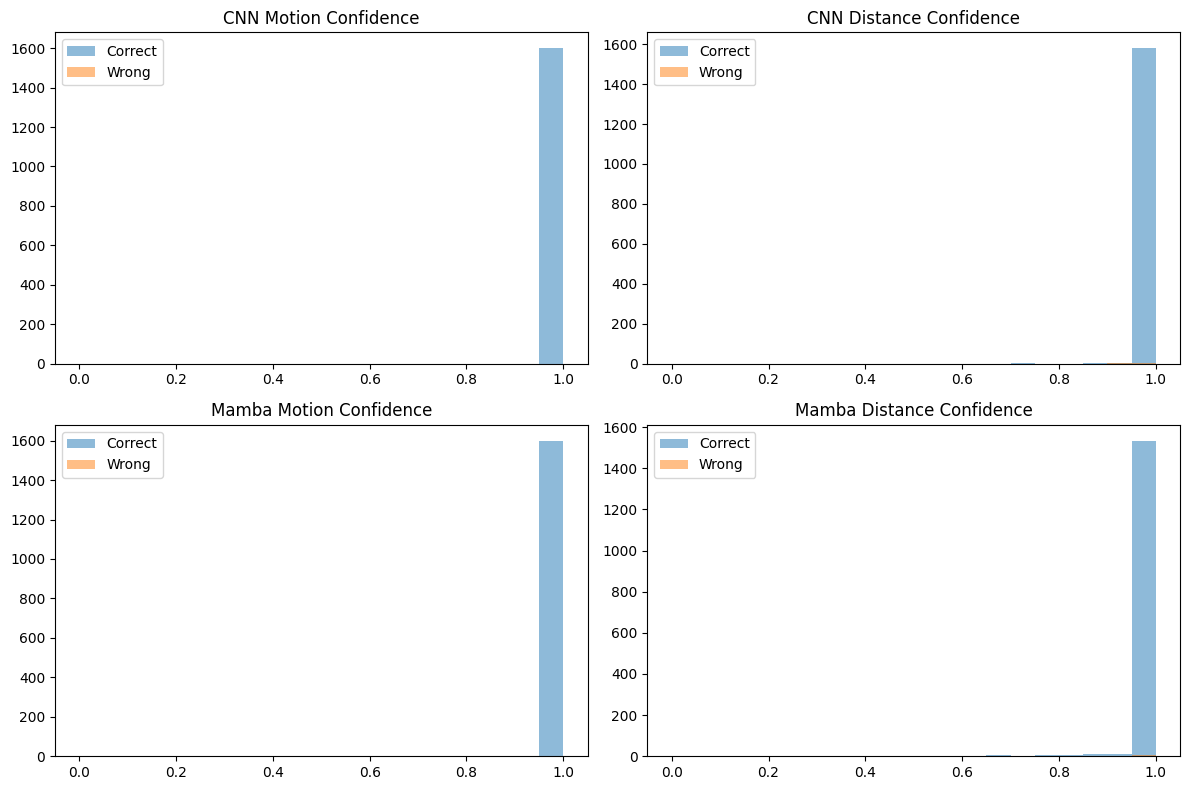

In [ ]:
def compute_confidence_entropy(model, X, device, is_mamba=False, batch_size=256):
    model.eval()
    dataset = torch.utils.data.TensorDataset(torch.FloatTensor(X))
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_probs_motion = []
    all_probs_dist = []
    with torch.no_grad():
        for (batch_X,) in tqdm(loader, desc='Computing confidence'):
            batch_X = batch_X.to(device)
            if is_mamba:
                m_out, d_out = model(batch_X)
            else:
                m_out, d_out, _ = model(batch_X)
            all_probs_motion.append(Func.softmax(m_out, dim=1).cpu().numpy())
            all_probs_dist.append(Func.softmax(d_out, dim=1).cpu().numpy())
    return np.vstack(all_probs_motion), np.vstack(all_probs_dist)

probs_motion_cnn, probs_dist_cnn = compute_confidence_entropy(cnn_model, X_all, device, is_mamba=False)
probs_motion_mamba, probs_dist_mamba = compute_confidence_entropy(mamba_model, X_all, device, is_mamba=True)

max_prob_motion_cnn = np.max(probs_motion_cnn, axis=1)
max_prob_dist_cnn = np.max(probs_dist_cnn, axis=1)
max_prob_motion_mamba = np.max(probs_motion_mamba, axis=1)
max_prob_dist_mamba = np.max(probs_dist_mamba, axis=1)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0,0].hist(max_prob_motion_cnn[true_motion_all == motion_pred_cnn_all], bins=20, range=(0,1), alpha=0.5, label='Correct')
axes[0,0].hist(max_prob_motion_cnn[true_motion_all != motion_pred_cnn_all], bins=20, range=(0,1), alpha=0.5, label='Wrong')
axes[0,0].set_title('CNN Motion Confidence')
axes[0,0].legend()
axes[0,1].hist(max_prob_dist_cnn[y_all == dist_pred_cnn_all], bins=20, alpha=0.5, range=(0,1), label='Correct')
axes[0,1].hist(max_prob_dist_cnn[y_all != dist_pred_cnn_all], bins=20, alpha=0.5, range=(0,1), label='Wrong')
axes[0,1].set_title('CNN Distance Confidence')
axes[0,1].legend()
axes[1,0].hist(max_prob_motion_mamba[true_motion_all == motion_pred_mamba_all], bins=20, range=(0,1), alpha=0.5, label='Correct')
axes[1,0].hist(max_prob_motion_mamba[true_motion_all != motion_pred_mamba_all], bins=20, range=(0,1), alpha=0.5, label='Wrong')
axes[1,0].set_title('Mamba Motion Confidence')
axes[1,0].legend()
axes[1,1].hist(max_prob_dist_mamba[y_all == dist_pred_mamba_all], bins=20, alpha=0.5, range=(0,1), label='Correct')
axes[1,1].hist(max_prob_dist_mamba[y_all != dist_pred_mamba_all], bins=20, alpha=0.5, range=(0,1), label='Wrong')
axes[1,1].set_title('Mamba Distance Confidence')
axes[1,1].legend()
plt.tight_layout()
plt.show()

### Robustness

Проверка на зашумленных данных. К исходному набору добавляется Гауссовский шум, метки остаются теми же. Для устойчивых моделей без сильного переобучения оценка не должна меняться

Evaluating with noise std=0.05: 100%|██████████| 7/7 [00:00<00:00,  8.58it/s]


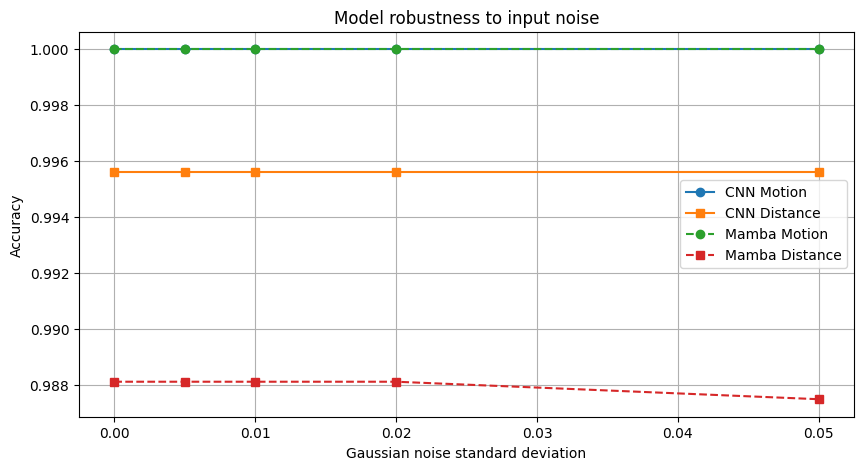

In [ ]:
def evaluate_with_noise(model, X, y, device, noise_std=0.01, is_mamba=False, batch_size=256):
    model.eval()
    dataset = torch.utils.data.TensorDataset(torch.FloatTensor(X), torch.LongTensor(y))
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False)
    all_motion_pred, all_dist_pred = [], []
    with torch.no_grad():
        for batch_X, _ in tqdm(loader, desc=f'Evaluating with noise std={noise_std}'):
            noise = torch.randn_like(batch_X) * noise_std
            batch_X_noisy = batch_X + noise
            batch_X_noisy = batch_X_noisy.to(device)
            if is_mamba:
                m_out, d_out = model(batch_X_noisy)
            else:
                m_out, d_out, _ = model(batch_X_noisy)
            all_motion_pred.extend(m_out.argmax(1).cpu().numpy())
            all_dist_pred.extend(d_out.argmax(1).cpu().numpy())
    return np.array(all_motion_pred), np.array(all_dist_pred)

noise_levels = [0.0, 0.005, 0.01, 0.02, 0.05]
cnn_motion_acc_noise = []
cnn_dist_acc_noise = []
mamba_motion_acc_noise = []
mamba_dist_acc_noise = []

for std in noise_levels:
    motion_pred, dist_pred = evaluate_with_noise(cnn_model, X_all, y_all, device, noise_std=std, is_mamba=False)
    cnn_motion_acc_noise.append(accuracy_score(true_motion_all, motion_pred))
    cnn_dist_acc_noise.append(accuracy_score(y_all, dist_pred))
    motion_pred, dist_pred = evaluate_with_noise(mamba_model, X_all, y_all, device, noise_std=std, is_mamba=True)
    mamba_motion_acc_noise.append(accuracy_score(true_motion_all, motion_pred))
    mamba_dist_acc_noise.append(accuracy_score(y_all, dist_pred))

plt.figure(figsize=(10,5))
plt.plot(noise_levels, cnn_motion_acc_noise, 'o-', label='CNN Motion')
plt.plot(noise_levels, cnn_dist_acc_noise, 's-', label='CNN Distance')
plt.plot(noise_levels, mamba_motion_acc_noise, 'o--', label='Mamba Motion')
plt.plot(noise_levels, mamba_dist_acc_noise, 's--', label='Mamba Distance')
plt.xlabel('Gaussian noise standard deviation')
plt.ylabel('Accuracy')
plt.title('Model robustness to input noise')
plt.legend()
plt.grid(True)
plt.show()

### Shuffle test

Перемешивание меток. Так как класса 4, а количество меток равномерно, попадание должно быть примерно 25% (случайное, аналог обычной точности)

In [ ]:
shuffled_y = np.random.permutation(y_all)
X_shuffled = X_all.copy()

train_size = int(0.8 * len(X_shuffled))
X_train_shuff, X_test_shuff = X_shuffled[:train_size], X_shuffled[train_size:]
y_train_shuff, y_test_shuff = shuffled_y[:train_size], shuffled_y[train_size:]

from sklearn.preprocessing import StandardScaler
scalers_shuff = [[StandardScaler() for _ in range(52)] for _ in range(3)]
for d in range(3):
    for f in range(52):
        scalers_shuff[d][f].fit(X_train_shuff[:, :, f, d].reshape(-1, 1))

def normalize_with_scalers(X, scalers):
    X_norm = np.zeros_like(X)
    for d in range(3):
        for f in range(52):
            X_norm[:, :, f, d] = scalers[d][f].transform(X[:, :, f, d].reshape(-1, 1)).reshape(-1, X.shape[1])
    return X_norm

X_train_norm_shuff = normalize_with_scalers(X_train_shuff, scalers_shuff)
X_test_norm_shuff = normalize_with_scalers(X_test_shuff, scalers_shuff)

class SimpleDataset(torch.utils.data.Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset_shuff = SimpleDataset(X_train_norm_shuff, y_train_shuff)
test_dataset_shuff = SimpleDataset(X_test_norm_shuff, y_test_shuff)
train_loader_shuff = torch.utils.data.DataLoader(train_dataset_shuff, batch_size=256, shuffle=True)
test_loader_shuff = torch.utils.data.DataLoader(test_dataset_shuff, batch_size=256, shuffle=False)

class ShuffleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv1d(52*3, 32, 3, padding='same')
        self.bn1 = nn.BatchNorm1d(32)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(32, 64, 3, padding='same')
        self.bn2 = nn.BatchNorm1d(64)
        self.pool2 = nn.MaxPool1d(2)
        self.lstm = nn.LSTM(64, 32, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(64, 4)
    def forward(self, x):
        B, T, F, D = x.shape
        x = x.permute(0, 3, 2, 1).reshape(B, F*D, T)
        x = self.pool1(Func.relu(self.bn1(self.conv1(x))))
        x = self.pool2(Func.relu(self.bn2(self.conv2(x))))
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        out = self.fc(lstm_out[:, -1, :])
        return out

shuffle_model = ShuffleCNN().to(device)
optimizer = torch.optim.Adam(shuffle_model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

for epoch in range(20):
    shuffle_model.train()
    for X_batch, y_batch in train_loader_shuff:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        out = shuffle_model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()

shuffle_model.eval()
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader_shuff:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        out = shuffle_model(X_batch)
        pred = out.argmax(1)
        correct += (pred == y_batch).sum().item()
        total += y_batch.size(0)
print(f"Accuracy on shuffled labels (test): {correct/total:.4f}")

Accuracy on shuffled labels (test): 0.2531
